# West Region ZIP Map — Fill by DSP, Border by Polygon
本 Notebook 会：
1) 读取你下载的 **ZCTA（邮编面）** 与 **州界** Shapefile；
2) 只保留美西（可自定义州列表）；
3) 合并生成的 `dsp_zipcodes.xlsx`（`by_zipcode` 表）；
5) 画图 —— **填充=服务商（dsp_name）**, **边框=线路（polygon）**；
6) 导出 `GeoJSON` 与 `PNG`。

> 运行前：把 `tl_2024_us_zcta520.zip` 和 `cb_2023_us_state_500k.zip` 放到 `./data/` 目录里（或改路径）。

In [1]:
# 如果你没装这些库，请先运行（可注释掉行末的 '!'、或在终端/conda环境里安装）
# !pip install geopandas shapely pyproj fiona matplotlib pandas openpyxl requests


In [2]:
from pathlib import Path
import os, io, zipfile, requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.ops import unary_union
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ==== 参数 ====
DATA_DIR = Path("data") 
DATA_DIR.mkdir(exist_ok=True)

# By Zipcode/By State底图
ZCTA_ZIP = DATA_DIR / "tl_2024_us_zcta520.zip"
STATE_ZIP = DATA_DIR / "cb_2023_us_state_500k.zip"

# Polygon/Zipcode/DSP关系表
EXCEL_PATH = Path("dsp_zipcodes.xlsx")
SHEET = "by_zipcode"

# 美西州（可按需调整）
WEST_STATES = ["CA","NV","AZ"]

# 输出文件名
OUT_GEOJSON = Path("west_dsp_polygon.geojson")
OUT_PNG = Path("west_dsp_polygon_map.png")


In [3]:
# === 解压 Shapefile（如果已解压过可跳过） ===
def unzip_if_needed(zip_path: Path, out_dir: Path):
    if not zip_path.exists():
        raise FileNotFoundError(f"缺少文件: {zip_path}. 请把下载的 ZIP 放到 {out_dir} 下，或修改路径。")
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(out_dir)

unzip_if_needed(ZCTA_ZIP, DATA_DIR)
unzip_if_needed(STATE_ZIP, DATA_DIR)

print("解压完成。文件位于:", DATA_DIR.resolve())


解压完成。文件位于: C:\Users\Siming Shen\Desktop\DSP分布图\data


In [4]:
# === 读取州界（Cartographic Boundary, 500k）并筛选美西 ===
state_shp = None
for p in DATA_DIR.glob("cb_2023_us_state_500k*.shp"):
    state_shp = p
    break
if state_shp is None:
    raise FileNotFoundError("未找到 cb_2023_us_state_500k 的 .shp 文件，请确认 ZIP 已解压在 data/。")

states = gpd.read_file(state_shp).to_crs(4326)
states = states[states["STUSPS"].isin(WEST_STATES)][["STUSPS","NAME","geometry"]]
if states.empty:
    raise RuntimeError("筛选后的美西州集合为空，请检查 WEST_STATES 列表是否正确。")

west_union = states.union_all()
print("已载入并筛选州界。州数量:", len(states))


已载入并筛选州界。州数量: 3


In [5]:
# === 读取全国 ZCTA（2024 版）并筛选美西范围 ===
zcta_shp = None
for p in DATA_DIR.glob("tl_2024_us_zcta520*.shp"):
    zcta_shp = p
    break
if zcta_shp is None:
    raise FileNotFoundError("未找到 tl_2024_us_zcta520 的 .shp 文件，请确认 ZIP 已解压在 data/。")

zcta = gpd.read_file(zcta_shp)[["ZCTA5CE20","geometry"]].to_crs(4326)
zcta = zcta.rename(columns={"ZCTA5CE20":"zipcode"}).copy()

# 空间粗筛：仅保留与美西并集相交的 ZCTA
zcta_west = zcta[zcta.intersects(west_union)].copy()
zcta_west.reset_index(drop=True, inplace=True)
print("全国 ZCTA 数:", len(zcta), "；美西区域 ZCTA 数:", len(zcta_west))


全国 ZCTA 数: 33791 ；美西区域 ZCTA 数: 2449


In [6]:
# # === 读取你的 by_zipcode 表，并合并 ===
# if not EXCEL_PATH.exists():
#     raise FileNotFoundError(f"未找到 {EXCEL_PATH}。请把 dsp_zipcodes.xlsx 放在当前目录，或修改 EXCEL_PATH。")

# df = pd.read_excel(EXCEL_PATH, sheet_name=SHEET, dtype={"zipcode": str})
# df["zipcode"] = df["zipcode"].astype(str).str.strip().str.zfill(5)
# df = df.drop_duplicates(subset=["zipcode","dsp_name","polygon"]).reset_index(drop=True)

# gdf = zcta_west.merge(df, on="zipcode", how="inner")
# print("合并后的记录数:", len(gdf), "；列:", list(gdf.columns))

# === 读取你的 by_zipcode 表，并合并 ===
if not EXCEL_PATH.exists():
    raise FileNotFoundError(f"未找到 {EXCEL_PATH}。请把 dsp_zipcodes.xlsx 放在当前目录，或修改 EXCEL_PATH。")

df = pd.read_excel(EXCEL_PATH, sheet_name=SHEET, dtype={"zipcode": str})
df["zipcode"] = df["zipcode"].astype(str).str.strip().str.zfill(5)

# 新增列清洗
df["transferred"] = df["transferred"].astype(str).str.strip()
df["num_package_per_day"] = pd.to_numeric(df["num_package_per_day"], errors="coerce").fillna(0)

# 去重时把新列也考虑进去，避免丢信息
df = df.drop_duplicates(
    subset=["zipcode", "dsp_name", "polygon", "transferred", "num_package_per_day"]
).reset_index(drop=True)

gdf = zcta_west.merge(df, on="zipcode", how="inner")

print("合并后的记录数:", len(gdf), "；列:", list(gdf.columns))
print(gdf[["zipcode", "dsp_name", "polygon", "transferred", "num_package_per_day"]].head())

合并后的记录数: 1101 ；列: ['zipcode', 'geometry', 'polygon', 'dsp_name', 'hub', 'transferred', 'num_package_per_day']
  zipcode              dsp_name       polygon transferred  num_package_per_day
0   89084  STA_LAS_WODLOGISTICS  CA-10-LAS-30           否                    2
1   89074        STA_LAS_Shunle  CA-10-LAS-38           否                    2
2   89119        STA_LAS_Shunle  CA-10-LAS-32           否                   50
3   89144  STA_LAS_WODLOGISTICS  CA-10-LAS-28           否                    0
4   89143  STA_LAS_WODLOGISTICS  CA-10-LAS-28           否                    1


In [7]:
# === 构建调色：填充按 dsp_name，边框按 polygon ===
import numpy as np
import matplotlib as mpl

dsp_cats = pd.Categorical(gdf["dsp_name"])
dsp_codes = dsp_cats.codes  # -1 表示缺失

cmap_fill = plt.cm.get_cmap("tab20", max(dsp_codes)+1 if dsp_codes.max()>=0 else 1)
fill_colors = np.array([cmap_fill(code) if code >= 0 else (0.8,0.8,0.8,1.0) for code in dsp_codes])

polys = sorted(gdf["polygon"].dropna().unique().tolist())
cmap_edge = plt.cm.get_cmap("tab10", max(1, len(polys)))
poly2color = {p: cmap_edge(i) for i, p in enumerate(polys)}


C:\Users\Siming Shen\AppData\Local\Temp\ipykernel_34236\2448602272.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_fill = plt.cm.get_cmap("tab20", max(dsp_codes)+1 if dsp_codes.max()>=0 else 1)
C:\Users\Siming Shen\AppData\Local\Temp\ipykernel_34236\2448602272.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_edge = plt.cm.get_cmap("tab10", max(1, len(polys)))


C:\Users\Siming Shen\AppData\Local\Temp\ipykernel_34236\3810813272.py:31: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Siming Shen\AppData\Local\Temp\ipykernel_34236\3810813272.py:31: UserWarning: Glyph 22635 (\N{CJK UNIFIED IDEOGRAPH-586B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Siming Shen\AppData\Local\Temp\ipykernel_34236\3810813272.py:31: UserWarning: Glyph 20805 (\N{CJK UNIFIED IDEOGRAPH-5145}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Siming Shen\AppData\Local\Temp\ipykernel_34236\3810813272.py:31: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Siming Shen\AppData\Local\Temp\ipykernel_34236\3810813272.py:31: UserWarning: Glyph 36793 (\N{CJK UNIFIED IDEOGRAPH-8FB9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Siming Shen\AppData\Local\Temp\ipykernel_34236\38108132

已保存 PNG: C:\Users\Siming Shen\Desktop\DSP分布图\west_dsp_polygon_map.png


C:\Users\Siming Shen\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Siming Shen\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22635 (\N{CJK UNIFIED IDEOGRAPH-586B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Siming Shen\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20805 (\N{CJK UNIFIED IDEOGRAPH-5145}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Siming Shen\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Siming She

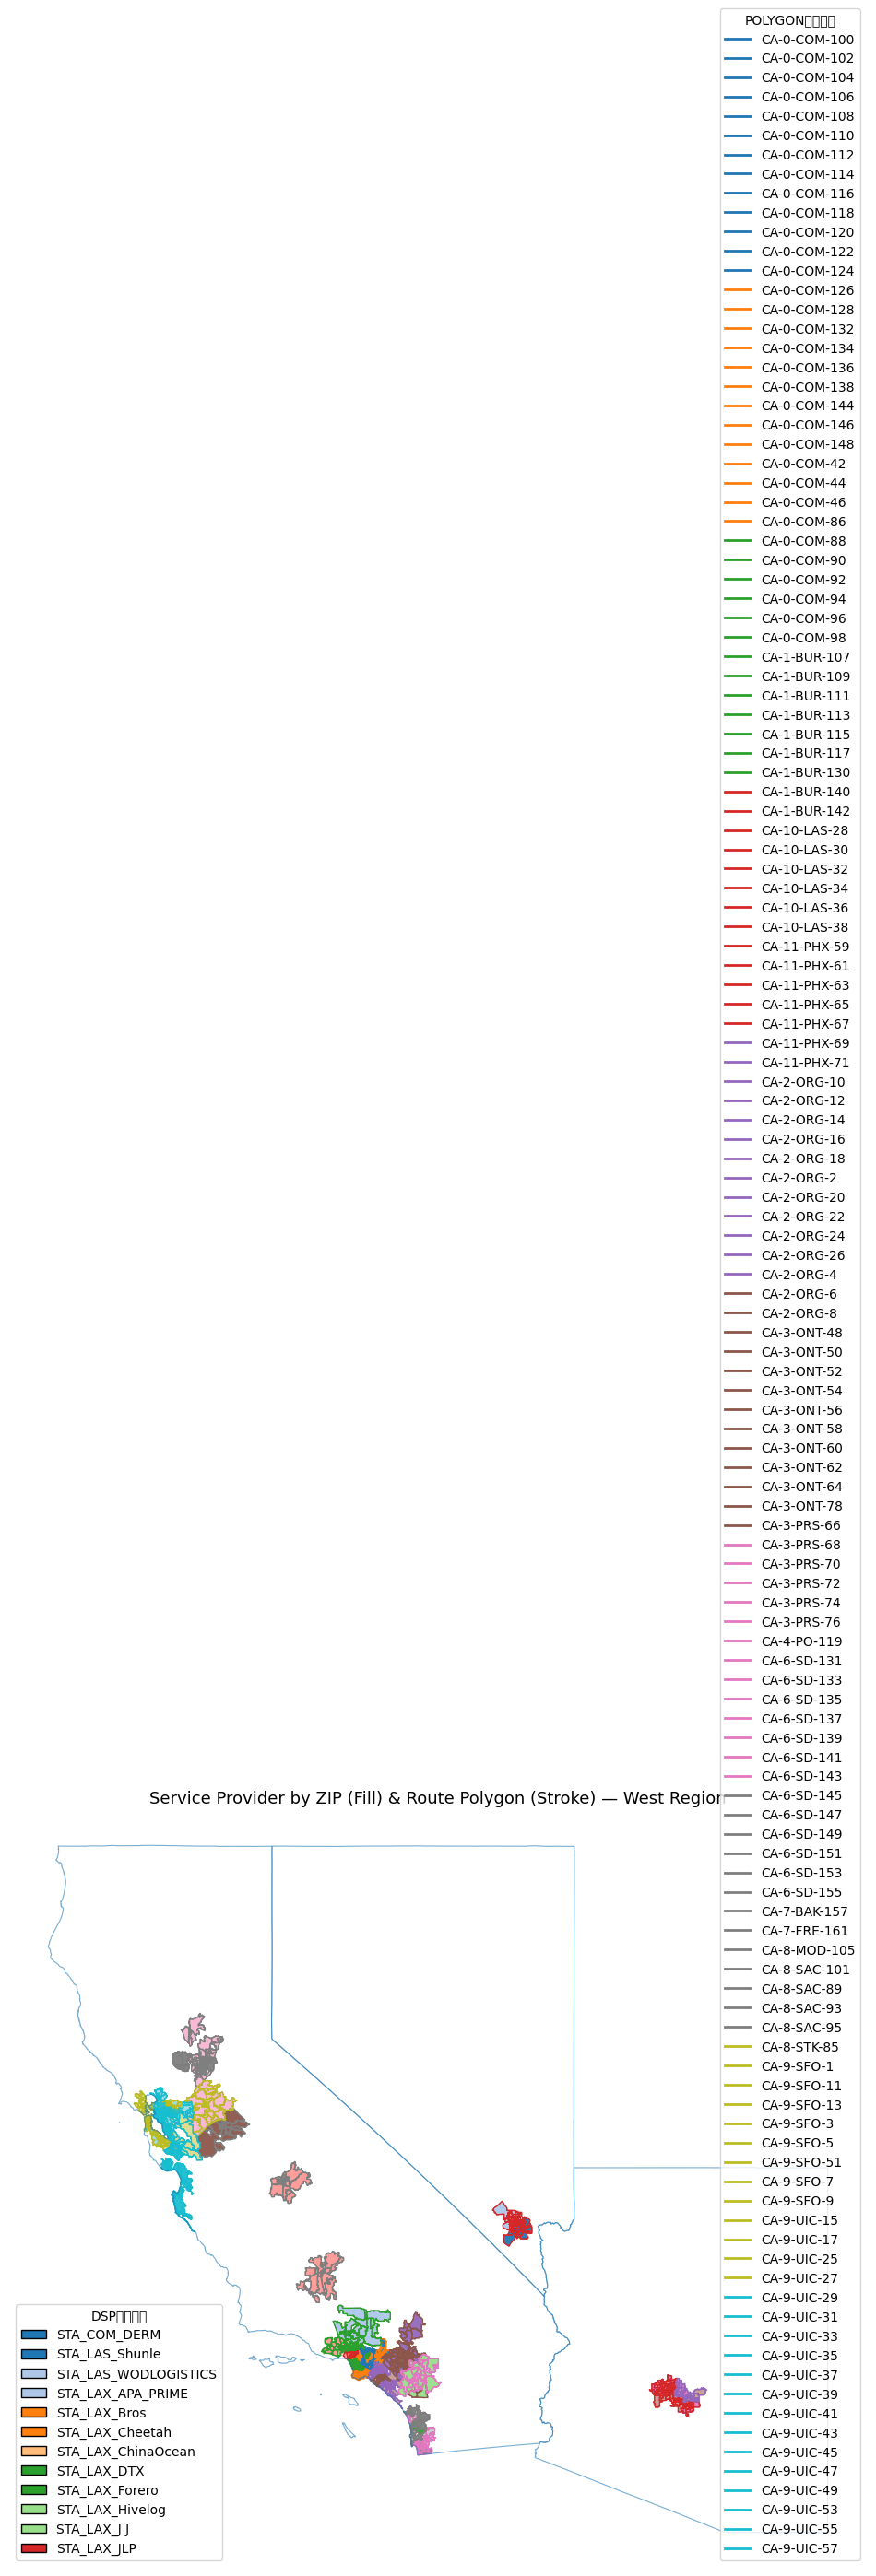

In [8]:
# === 画图 ===
fig, ax = plt.subplots(figsize=(12, 12))
states.boundary.plot(ax=ax, linewidth=0.8, alpha=0.6)

# 填充（服务商）
gdf.plot(ax=ax, color=fill_colors, linewidth=0.4, edgecolor="black", alpha=0.95)

# 边框（线路）
for p, sub in gdf.groupby("polygon"):
    edge_color = poly2color.get(p, (0,0,0,1))
    sub.plot(ax=ax, facecolor="none", edgecolor=edge_color, linewidth=1.0)

# 图例
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

dsp_handles = []
for dsp in list(dsp_cats.categories)[:12]:
    code = list(dsp_cats.categories).index(dsp)
    color = cmap_fill(code)
    dsp_handles.append(Patch(facecolor=color, edgecolor='black', label=str(dsp)))

leg1 = ax.legend(handles=dsp_handles, title="DSP（填充）", loc="lower left", frameon=True)
ax.add_artist(leg1)

poly_handles = [Line2D([0],[0], color=poly2color[p], linewidth=2, label=str(p)) for p in polys]
ax.legend(handles=poly_handles, title="POLYGON（边框）", loc="lower right", frameon=True)

ax.set_title("Service Provider by ZIP (Fill) & Route Polygon (Stroke) — West Region", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=220)
print(f"已保存 PNG: {OUT_PNG.resolve()}")


In [9]:
# === 导出 GeoJSON ===
gdf.to_file(OUT_GEOJSON, driver="GeoJSON")
print(f"已导出 GeoJSON: {OUT_GEOJSON.resolve()}")


已导出 GeoJSON: C:\Users\Siming Shen\Desktop\DSP分布图\west_dsp_polygon.geojson
